In [1]:
import json
from sentence_transformers import util
import numpy as np
from scipy import stats
import os
import pandas as pd

# Analysis code

## Funcs

In [16]:
def load_embeddings_from_jsonl(file_path):
    """
    Loads embeddings from a .jsonl file.

    Args:
        file_path (str): The path to the .jsonl file.

    Returns:
        np.array: A numpy array of sentence embeddings.
    """
    embeddings = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            embeddings.append(item['embedding'])
    return np.array(embeddings)


def calculate_semantic_metrics(embeddings):
    """
    Calculates semantic diversity and related metrics from sentence embeddings.

    Args:
        embeddings (np.array): A numpy array of sentence embeddings.

    Returns:
        tuple: A tuple containing:
            - cosine_distances (np.array): Pairwise cosine distances.
            - sem_div (float): The semantic diversity score (mean).
            - std_dev (float): The standard deviation of the cosine distances.
            - std_err (float): The standard error of the cosine distances.
    """
    similarities = util.pytorch_cos_sim(embeddings, embeddings).numpy()
    cosine_distances = 1 - similarities

    # Exclude self-comparisons from the diagonal
    mask = np.ones_like(cosine_distances, dtype=bool)
    np.fill_diagonal(mask, False)
    pairwise_distances = cosine_distances[mask]

    sem_div = np.mean(pairwise_distances)
    # ddof=1 for sample standard deviation
    std_dev = np.std(pairwise_distances, ddof=1)
    std_err = std_dev / np.sqrt(pairwise_distances.size)

    return cosine_distances, sem_div, std_dev, std_err

def process_embeddings_directory(input_dir, output_dir):
    """
    Processes all embedding files in a directory, calculates semantic metrics,
    and saves the results.

    Args:
        input_dir (str): The directory containing .jsonl embedding files.
        output_dir (str): The directory where results will be saved.

    Returns:
        pd.DataFrame: A DataFrame containing the summary of results.
                      Returns None if no files were processed.
    """
    os.makedirs(output_dir, exist_ok=True)
    results = []

    jsonl_files = [f for f in os.listdir(input_dir) if f.endswith('.jsonl')]
    
    if not jsonl_files:
        print(f"No .jsonl files found in '{input_dir}'.")
        return None

    # Define a sort order for the filenames to ensure consistent processing order
    order_keys = ['single', 'multi', 'human', 'dolly_test']
    def get_sort_key(filename):
        for i, key in enumerate(order_keys):
            if key in filename:
                return i
        return len(order_keys)  # Fallback for any files not matching the keys
    
    jsonl_files.sort(key=get_sort_key)

    for filename in jsonl_files:
        print(f"Processing {filename}...")
        input_path = os.path.join(input_dir, filename)

        try:
            embeddings = load_embeddings_from_jsonl(input_path)
        except (json.JSONDecodeError, IOError) as e:
            print(f"  Error reading {filename}: {e}. Skipping.")
            continue
            
        if embeddings.size == 0 or embeddings.ndim != 2:
            print(f"  Warning: No valid embeddings found in {filename}. Skipping.")
            continue

        cosine_distances, sem_div, std_dev, std_err = calculate_semantic_metrics(embeddings)

        base_name = os.path.splitext(filename)[0]
        distances_filename = f"cosine_distances_{base_name}.npy"
        distances_output_path = os.path.join(output_dir, distances_filename)
        np.save(distances_output_path, cosine_distances)

        results.append({
            'filename': base_name,
            'semantic_diversity': sem_div,
            'standard_deviation': std_dev,
            'standard_error': std_err
        })

        print(f"  Semantic Diversity: {sem_div:.4f} ± {std_err:.6f}")
        print(f"  Saved cosine distances to '{distances_output_path}'")

    if not results:
        print("\nNo files were successfully processed.")
        return None

    results_df = pd.DataFrame(results)
    csv_output_path = os.path.join(output_dir, 'semantic_diversity_summary.csv')
    results_df.to_csv(csv_output_path, index=False)

    print(f"\nSummary of results saved to '{csv_output_path}'")
    return results_df
def process_selected_files(file_paths, output_dir):
    """
    Processes a specific list of embedding files, calculates semantic metrics,
    and saves the results.

    Args:
        file_paths (list): A list of full paths to the .jsonl embedding files.
        output_dir (str): The directory where results will be saved.

    Returns:
        pd.DataFrame: A DataFrame containing the summary of results.
                      Returns None if no files were processed.
    """
    os.makedirs(output_dir, exist_ok=True)
    results = []

    if not file_paths:
        print("No files provided for processing.")
        return None
    
    # Define a sort order for the filenames to ensure consistent processing order
    order_keys = ['single', 'multi', 'human', 'dolly_test']
    def get_sort_key(filepath):
        filename = os.path.basename(filepath)
        for i, key in enumerate(order_keys):
            if key in filename:
                return i
        return len(order_keys)  # Fallback
    
    file_paths.sort(key=get_sort_key)

    for input_path in file_paths:
        filename = os.path.basename(input_path)
        print(f"Processing {filename}...")

        try:
            embeddings = load_embeddings_from_jsonl(input_path)
        except (json.JSONDecodeError, IOError) as e:
            print(f"  Error reading {filename}: {e}. Skipping.")
            continue
            
        if embeddings.size == 0 or embeddings.ndim != 2:
            print(f"  Warning: No valid embeddings found in {filename}. Skipping.")
            continue

        cosine_distances, sem_div, std_dev, std_err = calculate_semantic_metrics(embeddings)

        base_name = os.path.splitext(filename)[0]
        distances_filename = f"cosine_distances_{base_name}.npy"
        distances_output_path = os.path.join(output_dir, distances_filename)
        np.save(distances_output_path, cosine_distances)

        results.append({
            'filename': base_name,
            'semantic_diversity': sem_div,
            'standard_deviation': std_dev,
            'standard_error': std_err
        })

        print(f"  Semantic Diversity: {sem_div:.4f} ± {std_err:.6f}")
        print(f"  Saved cosine distances to '{distances_output_path}'")

    if not results:
        print("\nNo files were successfully processed.")
        return None

    results_df = pd.DataFrame(results)
    csv_output_path = os.path.join(output_dir, 'semantic_diversity_summary.csv')
    results_df.to_csv(csv_output_path, index=False)

    print(f"\nSummary of results saved to '{csv_output_path}'")
    return results_df


def get_label_from_filename(base_name):
    """Creates a readable label from a filename."""
    if 'single' in base_name:
        return 'Single-Source-Tuned'
    if 'multi' in base_name:
        return 'Multi-Source-Tuned'
    if 'human' in base_name:
        return 'Human-Tuned'
    if 'dolly_test' in base_name:
        return 'Vanilla (Llama)'
    return base_name # Fallback to the original name if no keyword is found

def run_analysis_for_size(size, input_dir, base_output_dir):
    """
    Runs a complete semantic diversity analysis for a specific finetuning data size.

    It selects the 'single_source' and 'multi_source' models of the specified
    size, along with the baseline 'human_source' and 'vanilla' models.

    Args:
        size (str): The size of the models to analyze ('small', 'medium', or 'large').
        input_dir (str): The directory containing all .jsonl embedding files.
        base_output_dir (str): The base directory where results for this size will be saved.
    """
    print(f"\n--- Running Analysis for Size: {size.upper()} ---")

    # 1. Define the filenames to be processed for the given size
    files_to_process = [
        f"output_llama_70b_single_source_{size}_embeddings.jsonl",
        f"output_llama_70b_multi_source_{size}_embeddings.jsonl",
        "output_llama_70b_human_source_embeddings.jsonl",
        "dolly_test_Llama_embeddings.jsonl"
    ]

    # Construct full paths and check for existence
    file_paths = []
    for f in files_to_process:
        path = os.path.join(input_dir, f)
        if os.path.exists(path):
            file_paths.append(path)
        else:
            print(f"Warning: File not found and will be skipped: {path}")

    if len(file_paths) < 2:
        print("\nError: Need at least two valid files to run an analysis. Aborting.")
        return

    # 2. Define a specific output directory for this size
    output_dir_for_size = os.path.join(base_output_dir, size)
    
    # 3. Run the processing pipeline on the selected files
    summary_df = process_selected_files(file_paths, output_dir_for_size)

    # 4. If processing was successful, run the statistical analysis
    if summary_df is not None:
        perform_statistical_analysis(output_dir_for_size, summary_df)
        
        print(f"\n--- Results Summary for {size.upper()} ---")
        display(summary_df)
    else:
        print(f"\n--- Analysis for {size.upper()} Failed: No data processed ---")

def perform_statistical_analysis(output_dir, summary_df):
    """
    Performs Levene's test and Kruskal-Wallis analysis on the generated
    cosine distance files.
    """
    all_distances = {}
    
    # Load all the cosine distance arrays
    for _, row in summary_df.iterrows():
        base_name = row['filename']
        label = get_label_from_filename(base_name)
        distances_path = os.path.join(output_dir, f"cosine_distances_{base_name}.npy")
        
        if os.path.exists(distances_path):
            cos_dist_matrix = np.load(distances_path)
            mask = np.ones_like(cos_dist_matrix, dtype=bool)
            np.fill_diagonal(mask, False)
            all_distances[label] = cos_dist_matrix[mask]
        else:
            print(f"Warning: Could not find distances file: {distances_path}")

    if len(all_distances) < 2:
        print("Need at least two groups to perform statistical tests.")
        return

    # Define the desired processing order for labels
    desired_order = ['Single-Source-Tuned', 'Multi-Source-Tuned', 'Human-Tuned', 'Vanilla (Llama)']
    order_map = {label: i for i, label in enumerate(desired_order)}

    # Sort the collected labels and corresponding groups based on the desired order
    current_labels = list(all_distances.keys())
    current_labels.sort(key=lambda x: order_map.get(x, len(desired_order)))
    
    labels = current_labels
    groups = [all_distances[label] for label in labels]

    print("\n--- Statistical Analysis ---")

    np.random.seed(42)
    n_sample = 10000
    
    can_sample = all(len(g) >= n_sample for g in groups)
    
    if can_sample:
        print(f"\nSampling {n_sample} distances from each group for statistical tests.")
        sampled_groups = [np.random.choice(g, size=n_sample, replace=False) for g in groups]
    else:
        print(f"\nOne or more groups has fewer than {n_sample} elements. Using full datasets for tests.")
        sampled_groups = groups

    # 1. Levene's Test for Homogeneity of Variances
    print("\n1. Levene's Test for Homogeneity of Variances:")
    stat_levene, p_levene = stats.levene(*sampled_groups)
    print(f"  Levene's test statistic: {stat_levene:.4f}, p-value: {p_levene:.4f}")
    if p_levene < 0.05:
        print("  Result: Variances are significantly different (p < 0.05).")
    else:
        print("  Result: Variances are not significantly different (p >= 0.05).")

    # 2. Kruskal-Wallis H-Test
    print("\n2. Kruskal-Wallis H-Test (non-parametric ANOVA):")
    H, p_kruskal = stats.kruskal(*sampled_groups)
    print(f"  H-statistic: {H:.2f}, p-value: {p_kruskal:.4f}")

    # 3. Pairwise Comparisons (if Kruskal-Wallis is significant)
    if p_kruskal < 0.05:
        print("\n3. Pairwise Comparisons (Mann-Whitney U test with Bonferroni correction):")
        
        n_comparisons = len(labels) * (len(labels) - 1) // 2
        alpha = 0.05 / n_comparisons
        print(f"  Corrected significance level (alpha): {alpha:.6f}")

        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                stat_mw, p_mw = stats.mannwhitneyu(sampled_groups[i], sampled_groups[j], alternative='two-sided')
                print(f"\n  - {labels[i]} vs {labels[j]}:")
                print(f"    U-statistic: {stat_mw:.2f}, p-value: {p_mw:.2e}")
                print(f"    Significant difference: {'Yes' if p_mw < alpha else 'No'}")
    else:
        print("\nKruskal-Wallis test is not significant; no pairwise comparisons needed.")

## Small models

In [17]:
INPUT_DIR = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/sentence_embeddings"
parent_dir = os.path.dirname(INPUT_DIR)
OUTPUT_DIR = os.path.join(parent_dir, "semantic_diversity_results")

# 2. Run the main processing pipeline to calculate metrics
summary_df = process_embeddings_directory(INPUT_DIR, OUTPUT_DIR)

# 3. If processing was successful, run the statistical analysis
if summary_df is not None:
    perform_statistical_analysis(OUTPUT_DIR, summary_df)
    
    print("\n--- Results Summary ---")
    display(summary_df) # Use display() for better formatting in notebooks


Processing output_lora_llama_8b_single_embeddings.jsonl...
  Semantic Diversity: 0.9565 ± 0.000017
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/semantic_diversity_results/cosine_distances_output_lora_llama_8b_single_embeddings.npy'
Processing output_lora_llama_8b_multi_embeddings.jsonl...
  Semantic Diversity: 0.9535 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/semantic_diversity_results/cosine_distances_output_lora_llama_8b_multi_embeddings.npy'
Processing output_lora_llama_8b_human_embeddings.jsonl...
  Semantic Diversity: 0.9680 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/semantic_diversity_results/cosine_distances_output_lora_llama_8b_human_embeddings.npy'
Processing dolly_test_Llama_embeddings.jsonl...
  Semantic Diversity: 0.9547 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small

,filename,semantic_diversity,standard_deviation,standard_error
0,output_lora_llama_8b_single_embeddings,0.956516,0.087351,0.000017
1,output_lora_llama_8b_multi_embeddings,0.953474,0.088068,0.000018
2,output_lora_llama_8b_human_embeddings,0.968035,0.088162,0.000018
3,dolly_test_Llama_embeddings,0.954650,0.087720,0.000018


## Medium models

In [14]:
INPUT_DIR = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/sentence_embeddings"
parent_dir = os.path.dirname(INPUT_DIR)
OUTPUT_DIR = os.path.join(parent_dir, "semantic_diversity_results")

# 2. Run the main processing pipeline to calculate metrics
summary_df = process_embeddings_directory(INPUT_DIR, OUTPUT_DIR)

# 3. If processing was successful, run the statistical analysis
if summary_df is not None:
    perform_statistical_analysis(OUTPUT_DIR, summary_df)
    
    print("\n--- Results Summary ---")
    display(summary_df) # Use display() for better formatting in notebooks


Processing output_llama_70b_single_source_large_embeddings.jsonl...
  Semantic Diversity: 0.9544 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results/cosine_distances_output_llama_70b_single_source_large_embeddings.npy'
Processing output_llama_70b_single_source_medium_embeddings.jsonl...
  Semantic Diversity: 0.9546 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results/cosine_distances_output_llama_70b_single_source_medium_embeddings.npy'
Processing output_llama_70b_single_source_small_embeddings.jsonl...
  Semantic Diversity: 0.9559 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results/cosine_distances_output_llama_70b_single_source_small_embeddings.npy'
Processing output_llama_70b_multi_source_small_embeddings.jsonl...
  Semantic Diversity: 0.9539 ± 0.000018


,filename,semantic_diversity,standard_error
0,output_llama_70b_single_source_large_embeddings,0.954366,0.000018
1,output_llama_70b_single_source_medium_embeddings,0.954551,0.000018
2,output_llama_70b_single_source_small_embeddings,0.955911,0.000018
3,output_llama_70b_multi_source_small_embeddings,0.953933,0.000018
4,output_llama_70b_multi_source_medium_embeddings,0.955047,0.000018
5,output_llama_70b_multi_source_large_embeddings,0.945458,0.000018
6,output_llama_70b_human_source_embeddings,0.969597,0.000017
7,dolly_test_Llama_embeddings,0.952061,0.000018


In [18]:
# 1. Define input and base output directories
INPUT_DIR = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/sentence_embeddings"
parent_dir = os.path.dirname(INPUT_DIR)
# NOTE: This is now a *base* directory for categorized results
BASE_OUTPUT_DIR = os.path.join(parent_dir, "semantic_diversity_results_by_size")

# 2. Run the analysis for each size you want to compare
# The function will handle file selection, processing, and statistical tests.
run_analysis_for_size('small', INPUT_DIR, BASE_OUTPUT_DIR)
run_analysis_for_size('medium', INPUT_DIR, BASE_OUTPUT_DIR)
run_analysis_for_size('large', INPUT_DIR, BASE_OUTPUT_DIR)


--- Running Analysis for Size: SMALL ---
Processing output_llama_70b_single_source_small_embeddings.jsonl...
  Semantic Diversity: 0.9559 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/small/cosine_distances_output_llama_70b_single_source_small_embeddings.npy'
Processing output_llama_70b_multi_source_small_embeddings.jsonl...
  Semantic Diversity: 0.9539 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/small/cosine_distances_output_llama_70b_multi_source_small_embeddings.npy'
Processing output_llama_70b_human_source_embeddings.jsonl...
  Semantic Diversity: 0.9696 ± 0.000017
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/small/cosine_distances_output_llama_70b_human_source_embeddings.npy'
Processing dolly_test_Llama_embeddings.js

,filename,semantic_diversity,standard_deviation,standard_error
0,output_llama_70b_single_source_small_embeddings,0.955911,0.087574,0.000018
1,output_llama_70b_multi_source_small_embeddings,0.953933,0.088150,0.000018
2,output_llama_70b_human_source_embeddings,0.969597,0.085451,0.000017
3,dolly_test_Llama_embeddings,0.952061,0.088562,0.000018



--- Running Analysis for Size: MEDIUM ---
Processing output_llama_70b_single_source_medium_embeddings.jsonl...
  Semantic Diversity: 0.9546 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/medium/cosine_distances_output_llama_70b_single_source_medium_embeddings.npy'
Processing output_llama_70b_multi_source_medium_embeddings.jsonl...
  Semantic Diversity: 0.9550 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/medium/cosine_distances_output_llama_70b_multi_source_medium_embeddings.npy'
Processing output_llama_70b_human_source_embeddings.jsonl...
  Semantic Diversity: 0.9696 ± 0.000017
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/medium/cosine_distances_output_llama_70b_human_source_embeddings.npy'
Processing dolly_test_Llama_embed

,filename,semantic_diversity,standard_deviation,standard_error
0,output_llama_70b_single_source_medium_embeddings,0.954551,0.088279,0.000018
1,output_llama_70b_multi_source_medium_embeddings,0.955047,0.087824,0.000018
2,output_llama_70b_human_source_embeddings,0.969597,0.085451,0.000017
3,dolly_test_Llama_embeddings,0.952061,0.088562,0.000018



--- Running Analysis for Size: LARGE ---
Processing output_llama_70b_single_source_large_embeddings.jsonl...
  Semantic Diversity: 0.9544 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/large/cosine_distances_output_llama_70b_single_source_large_embeddings.npy'
Processing output_llama_70b_multi_source_large_embeddings.jsonl...
  Semantic Diversity: 0.9455 ± 0.000018
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/large/cosine_distances_output_llama_70b_multi_source_large_embeddings.npy'
Processing output_llama_70b_human_source_embeddings.jsonl...
  Semantic Diversity: 0.9696 ± 0.000017
  Saved cosine distances to '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results_by_size/large/cosine_distances_output_llama_70b_human_source_embeddings.npy'
Processing dolly_test_Llama_embeddings.js

,filename,semantic_diversity,standard_deviation,standard_error
0,output_llama_70b_single_source_large_embeddings,0.954366,0.088227,0.000018
1,output_llama_70b_multi_source_large_embeddings,0.945458,0.090601,0.000018
2,output_llama_70b_human_source_embeddings,0.969597,0.085451,0.000017
3,dolly_test_Llama_embeddings,0.952061,0.088562,0.000018


# Pairwise kruskall wallis h test over all cosine distances

## Bonferroni corrected

In [2]:
import os
import itertools
import numpy as np
import pandas as pd
from scipy import stats

def perform_full_pairwise_analysis():
    """
    Loads all semantic diversity distance files, performs a pairwise statistical
    analysis, and saves the results to CSV files.
    """
    # --- 1. Setup and Data Loading ---
    dirs_to_process = [
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/semantic_diversity_results',
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results'
    ]
    
    all_distances = {}
    print("--- Loading data files ---")
    for directory in dirs_to_process:
        if not os.path.exists(directory):
            print(f"Warning: Directory not found, skipping: {directory}")
            continue
            
        # Extract model size (e.g., 'small', 'medium') from the path for unique labels
        model_size = os.path.basename(os.path.dirname(os.path.dirname(directory)))
        
        for filename in os.listdir(directory):
            if filename.endswith('.npy'):
                # Create a clean, unique label from the filename
                base_name = filename.replace('cosine_distances_', '').replace('_embeddings.npy', '')
                label = f"{model_size}_{base_name}" # Prepend model size for uniqueness
                full_path = os.path.join(directory, filename)
                
                print(f"Loading: {label}")
                
                # Load the distance matrix and extract the pairwise distances
                cos_dist_matrix = np.load(full_path)
                mask = np.ones_like(cos_dist_matrix, dtype=bool)
                np.fill_diagonal(mask, False)
                all_distances[label] = cos_dist_matrix[mask]

    if not all_distances:
        print("Error: No .npy files were found. Aborting.")
        return

    # --- 2. Statistical Analysis ---
    labels = sorted(list(all_distances.keys()))
    n = len(labels)
    n_comparisons = n * (n - 1) // 2
    
    if n_comparisons <= 0:
        print("Error: Not enough files to perform pairwise comparison.")
        return
        
    corrected_alpha = 0.05 / n_comparisons

    print(f"\n--- Performing Pairwise Analysis ---")
    print(f"Found {n} files, performing {n_comparisons} pairwise comparisons.")
    print(f"Bonferroni-corrected significance level (alpha): {corrected_alpha:.6f}")

    # Initialize result matrices
    p_value_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
    significance_matrix = pd.DataFrame(index=labels, columns=labels, dtype=bool)

    # Set diagonals (comparison against self)
    np.fill_diagonal(p_value_matrix.values, 1.0)
    np.fill_diagonal(significance_matrix.values, False)

    # Use a fixed seed for reproducible sampling
    np.random.seed(42)
    n_sample = 10000

    # Iterate through all unique pairs
    for label1, label2 in itertools.combinations(labels, 2):
        group1 = all_distances[label1]
        group2 = all_distances[label2]

        # Sample from distributions for efficiency if they are large enough
        if len(group1) >= n_sample and len(group2) >= n_sample:
            sampled_group1 = np.random.choice(group1, n_sample, replace=False)
            sampled_group2 = np.random.choice(group2, n_sample, replace=False)
        else:
            # If any group is too small, use the full datasets
            sampled_group1 = group1
            sampled_group2 = group2

        # Perform Mann-Whitney U test
        _, p_val = stats.mannwhitneyu(sampled_group1, sampled_group2, alternative='two-sided')

        # Populate matrices (symmetrically)
        p_value_matrix.loc[label1, label2] = p_value_matrix.loc[label2, label1] = p_val
        is_significant = p_val < corrected_alpha
        significance_matrix.loc[label1, label2] = significance_matrix.loc[label2, label1] = is_significant

    # --- 3. Save Results ---
    # The files will be saved in the directory where the script is executed.
    output_path_significance = 'significance_matrix.csv'
    output_path_p_values = f'p_value_matrix_alpha_{corrected_alpha:.6f}.csv'

    significance_matrix.to_csv(output_path_significance)
    p_value_matrix.to_csv(output_path_p_values)

    print(f"\n--- Process Complete ---")
    print(f"Significance matrix saved to: {os.path.abspath(output_path_significance)}")
    print(f"P-value matrix saved to: {os.path.abspath(output_path_p_values)}")


# --- Run the analysis ---
perform_full_pairwise_analysis()

--- Loading data files ---
Loading: small_output_lora_llama_8b_single
Loading: small_dolly_test_Llama
Loading: small_output_lora_llama_8b_human
Loading: small_output_lora_llama_8b_multi
Loading: medium_output_llama_70b_multi_source_large
Loading: medium_output_llama_70b_multi_source_medium
Loading: medium_dolly_test_Llama
Loading: medium_output_llama_70b_single_source_large
Loading: medium_output_llama_70b_single_source_medium
Loading: medium_output_llama_70b_single_source_small
Loading: medium_output_llama_70b_multi_source_small
Loading: medium_output_llama_70b_human_source

--- Performing Pairwise Analysis ---
Found 12 files, performing 66 pairwise comparisons.
Bonferroni-corrected significance level (alpha): 0.000758

--- Process Complete ---
Significance matrix saved to: /Users/maxschaffelder/Desktop/Thesis/code/exp_1/metric_calculation/sem_div/significance_matrix.csv
P-value matrix saved to: /Users/maxschaffelder/Desktop/Thesis/code/exp_1/metric_calculation/sem_div/p_value_matrix_

In [6]:
import pandas as pd

sig_matrix = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/code/exp_1/metric_calculation/sem_div/significance_matrix.csv")
display(sig_matrix)


,Unnamed: 0,medium_dolly_test_Llama,medium_output_llama_70b_human_source,medium_output_llama_70b_multi_source_large,medium_output_llama_70b_multi_source_medium,medium_output_llama_70b_multi_source_small,medium_output_llama_70b_single_source_large,medium_output_llama_70b_single_source_medium,medium_output_llama_70b_single_source_small,small_dolly_test_Llama,small_output_lora_llama_8b_human,small_output_lora_llama_8b_multi,small_output_lora_llama_8b_single
0,medium_dolly_test_Llama,False,True,True,False,False,False,True,True,False,True,False,True
1,medium_output_llama_70b_human_source,True,False,True,True,True,True,True,True,True,False,True,True
2,medium_output_llama_70b_multi_source_large,True,True,False,True,True,True,True,True,True,True,True,True
3,medium_output_llama_70b_multi_source_medium,False,True,True,False,False,False,False,False,False,True,False,False
4,medium_output_llama_70b_multi_source_small,False,True,True,False,False,False,False,False,False,True,False,False
5,medium_output_llama_70b_single_source_large,False,True,True,False,False,False,False,False,False,True,False,False
6,medium_output_llama_70b_single_source_medium,True,True,True,False,False,False,False,False,False,True,False,False
7,medium_output_llama_70b_single_source_small,True,True,True,False,False,False,False,False,False,True,True,False
8,small_dolly_test_Llama,False,True,True,False,False,False,False,False,False,True,False,False
9,small_output_lora_llama_8b_human,True,False,True,True,True,True,True,True,True,False,True,True


## Holm-Bonferroni corrected

In [13]:
import os
import itertools
import numpy as np
import pandas as pd
from scipy import stats

def perform_full_pairwise_analysis():
    """
    Loads all semantic diversity distance files, performs a pairwise statistical
    analysis using the Holm-Bonferroni method, and saves the results.
    """
    # --- 1. Setup and Data Loading ---
    dirs_to_process = [
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/sem_div/semantic_diversity_results',
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/semantic_diversity_results'
    ]
    
    all_distances = {}
    print("--- Loading data files ---")
    for directory in dirs_to_process:
        if not os.path.exists(directory):
            print(f"Warning: Directory not found, skipping: {directory}")
            continue
            
        model_size = os.path.basename(os.path.dirname(os.path.dirname(directory)))
        
        for filename in os.listdir(directory):
            if filename.endswith('.npy'):
                base_name = filename.replace('cosine_distances_', '').replace('_embeddings.npy', '')
                label = f"{model_size}_{base_name}"
                full_path = os.path.join(directory, filename)
                
                print(f"Loading: {label}")
                
                cos_dist_matrix = np.load(full_path)
                mask = np.ones_like(cos_dist_matrix, dtype=bool)
                np.fill_diagonal(mask, False)
                all_distances[label] = cos_dist_matrix[mask]

    if not all_distances:
        print("Error: No .npy files were found. Aborting.")
        return

    # --- 2. Statistical Analysis ---
    labels = sorted(list(all_distances.keys()))
    n = len(labels)
    
    if n < 2:
        print("Error: Not enough files to perform pairwise comparison.")
        return
        
    print(f"\n--- Performing Pairwise Analysis (Holm-Bonferroni method) ---")
    print(f"Found {n} files, performing {n * (n - 1) // 2} pairwise comparisons.")

    p_value_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
    np.fill_diagonal(p_value_matrix.values, 1.0)
    
    p_values_list = []
    
    np.random.seed(42)
    n_sample = 10000

    # First, calculate all pairwise p-values
    for label1, label2 in itertools.combinations(labels, 2):
        group1 = all_distances[label1]
        group2 = all_distances[label2]

        if len(group1) >= n_sample and len(group2) >= n_sample:
            sampled_group1 = np.random.choice(group1, n_sample, replace=False)
            sampled_group2 = np.random.choice(group2, n_sample, replace=False)
        else:
            sampled_group1 = group1
            sampled_group2 = group2

        _, p_val = stats.mannwhitneyu(sampled_group1, sampled_group2, alternative='two-sided')
        
        p_value_matrix.loc[label1, label2] = p_value_matrix.loc[label2, label1] = p_val
        p_values_list.append((p_val, label1, label2))

    # Second, apply the Holm-Bonferroni correction
    # Sort p-values from smallest to largest
    p_values_list.sort()
    
    significance_matrix = pd.DataFrame(False, index=labels, columns=labels)
    np.fill_diagonal(significance_matrix.values, False)
    
    n_comparisons = len(p_values_list)
    
    print("\nApplying Holm-Bonferroni correction...")
    for k, (p_val, label1, label2) in enumerate(p_values_list):
        # The adjusted alpha for the k-th smallest p-value
        holm_alpha = 0.05 / (n_comparisons - k)
        
        if p_val < holm_alpha:
            # This result is significant
            significance_matrix.loc[label1, label2] = significance_matrix.loc[label2, label1] = True
        else:
            # Since p-values are sorted, once we find one that is not significant,
            # no subsequent (larger) p-values will be significant either.
            print(f"Stopped at k={k+1}: p-value {p_val:.4f} > adjusted alpha {holm_alpha:.4f}")
            break
            
    # --- 3. Save Results ---
    output_path_significance = 'significance_matrix_holm.csv'
    output_path_p_values = 'p_value_matrix.csv'

    significance_matrix.to_csv(output_path_significance)
    p_value_matrix.to_csv(output_path_p_values)

    print(f"\n--- Process Complete ---")
    print(f"Significance matrix (Holm-Bonferroni) saved to: {os.path.abspath(output_path_significance)}")
    print(f"Raw p-value matrix saved to: {os.path.abspath(output_path_p_values)}")


# --- Run the analysis ---
perform_full_pairwise_analysis()

--- Loading data files ---
Loading: small_output_lora_llama_8b_single
Loading: small_dolly_test_Llama
Loading: small_output_lora_llama_8b_human
Loading: small_output_lora_llama_8b_multi
Loading: medium_output_llama_70b_multi_source_large
Loading: medium_output_llama_70b_multi_source_medium
Loading: medium_dolly_test_Llama
Loading: medium_output_llama_70b_single_source_large
Loading: medium_output_llama_70b_single_source_medium
Loading: medium_output_llama_70b_single_source_small
Loading: medium_output_llama_70b_multi_source_small
Loading: medium_output_llama_70b_human_source

--- Performing Pairwise Analysis (Holm-Bonferroni method) ---
Found 12 files, performing 66 pairwise comparisons.

Applying Holm-Bonferroni correction...
Stopped at k=34: p-value 0.0125 > adjusted alpha 0.0015

--- Process Complete ---
Significance matrix (Holm-Bonferroni) saved to: /Users/maxschaffelder/Desktop/Thesis/code/exp_1/metric_calculation/sem_div/significance_matrix_holm.csv
Raw p-value matrix saved to: 

### Heat map

Heatmap saved to: /Users/maxschaffelder/Desktop/Thesis/code/exp_1/metric_calculation/sem_div/p_value_heatmap_holm_final.png


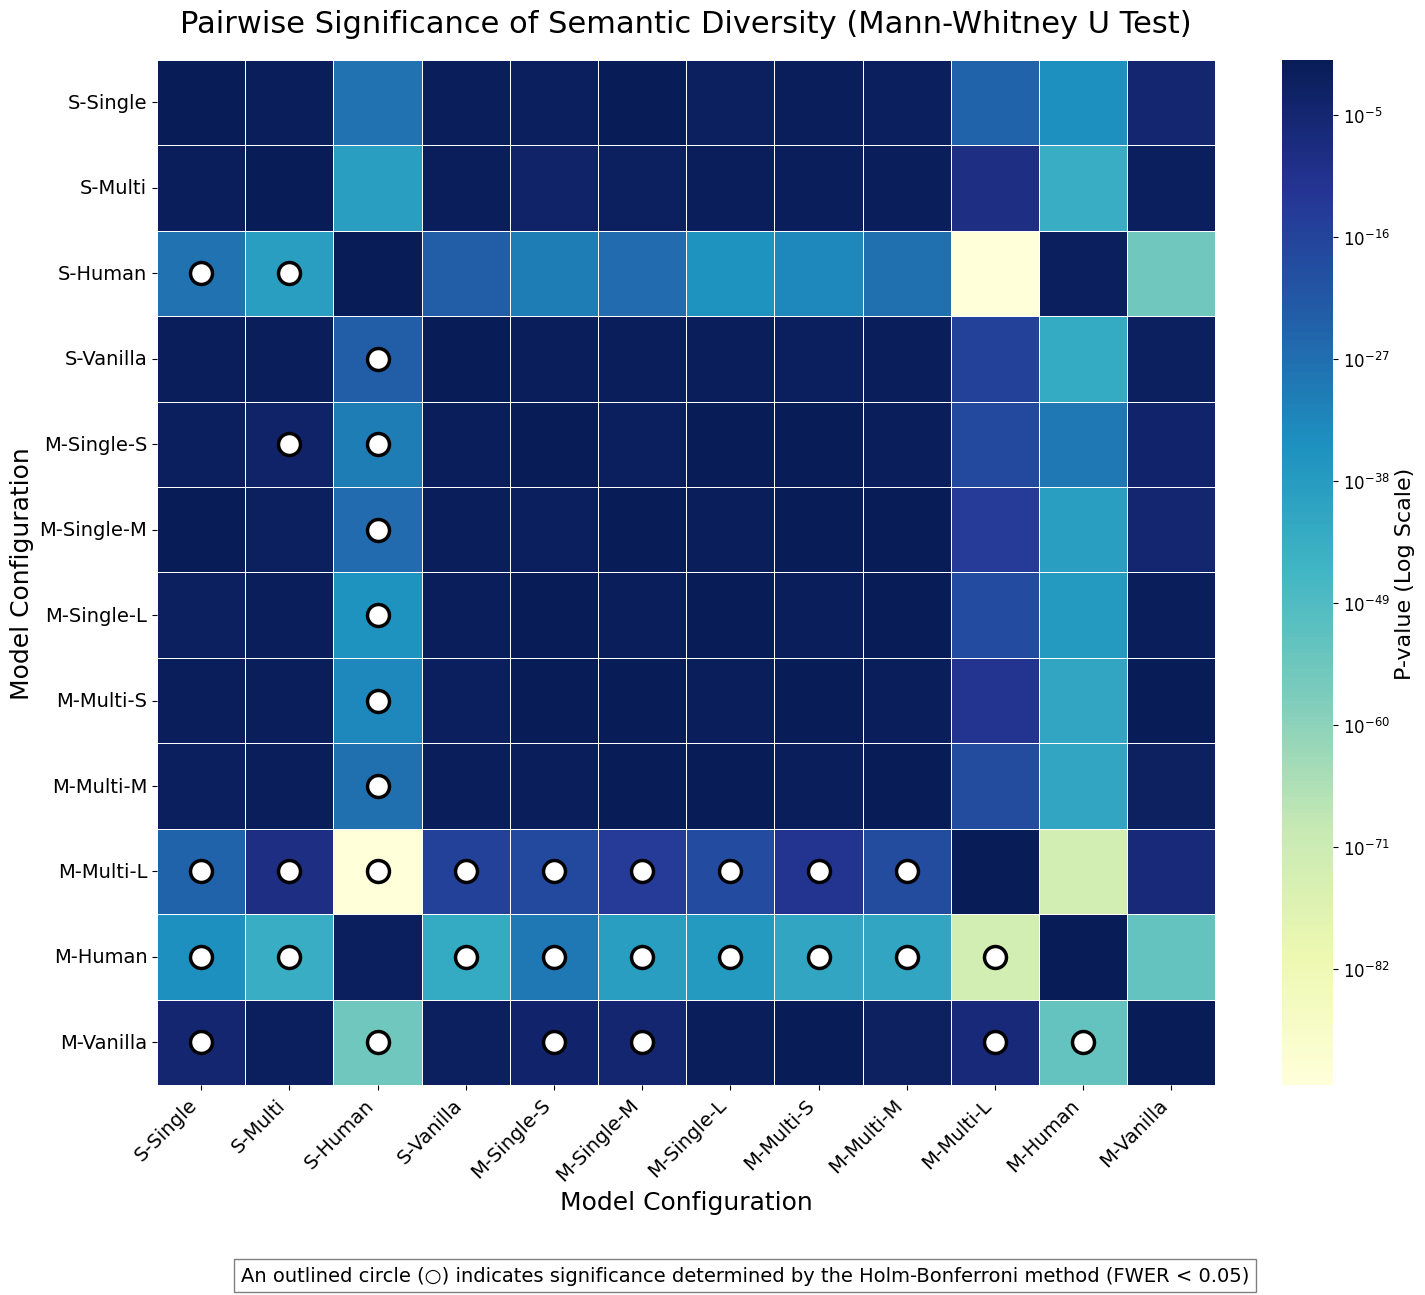

In [19]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

def abbreviate_label(label):
    """Creates a short, readable label from the long filename."""
    # Model size prefix
    if label.startswith('small_'):
        model = 'S'
        # Handle small model names which have a different pattern
        if label == 'small_output_lora_llama_8b_single':
            return 'S-Single'
        if label == 'small_output_lora_llama_8b_multi':
            return 'S-Multi'
        # Process other small models (human, dolly)
        label = label.replace('small_output_lora_llama_8b_', '')

    elif label.startswith('medium_'):
        model = 'M'
        label = label.replace('medium_output_llama_70b_', '')
    else:
        return '?' # Fallback for unknown format

    # Finetuning condition based on remaining label part
    if 'single_source' in label:
        condition = 'Single'
    elif 'multi_source' in label:
        condition = 'Multi'
    elif 'human_source' in label or 'human' in label:
        return 'M-Human' if model == 'M' else 'S-Human'
    elif 'dolly_test' in label:
        return 'M-Vanilla' if model == 'M' else 'S-Vanilla'
    else:
        # This should no longer be reached
        print(f"Warning: Unhandled label component: '{label}'")
        return '?'

    # Data size (primarily for medium models)
    if 'small' in label:
        data_size = 'S'
    elif 'medium' in label:
        data_size = 'M'
    elif 'large' in label:
        data_size = 'L'
    else:
        # Should not happen for medium finetuned models
        return f"{model}-{condition}"
        
    return f"{model}-{condition}-{data_size}"

def create_heatmap(p_values_path, significance_path):
    """
    Generates and saves a publication-ready heatmap, marking significant
    values with an outlined circle and using larger fonts and a custom-style colormap.
    """
    # Load both the p-value data and the significance data
    try:
        p_values = pd.read_csv(p_values_path, index_col=0)
        significance = pd.read_csv(significance_path, index_col=0)
    except FileNotFoundError as e:
        print(f"Error: A required file was not found: {e.filename}")
        print("Please make sure the script is in the same directory as both CSV files.")
        return

    # Abbreviate the labels for both dataframes to ensure they match
    short_labels = [abbreviate_label(label) for label in p_values.columns]
    p_values.columns = short_labels
    p_values.index = short_labels
    significance.columns = short_labels
    significance.index = short_labels

    # Define the custom order for the axes
    custom_order = [
        # Small models
        'S-Single', 'S-Multi', 'S-Human', 'S-Vanilla',
        # Medium models (ordered by finetuning type, then data size)
        'M-Single-S', 'M-Single-M', 'M-Single-L',
        'M-Multi-S', 'M-Multi-M', 'M-Multi-L',
        'M-Human', 'M-Vanilla'
    ]
    
    # Filter the order to only include labels present in the dataframe
    ordered_labels = [label for label in custom_order if label in p_values.columns]
    
    # Reorder both DataFrames to match the custom order
    p_values = p_values.reindex(index=ordered_labels, columns=ordered_labels)
    significance = significance.reindex(index=ordered_labels, columns=ordered_labels)

    plt.figure(figsize=(15, 13))
    
    min_val = p_values[p_values > 0].min().min()
    norm = LogNorm(vmin=min_val, vmax=1.0)
    
    # Draw the heatmap without annotations
    ax = sns.heatmap(
        p_values,
        cmap='YlGnBu',
        norm=norm,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'P-value (Log Scale)'}
    )

    # Add outlined circle markers for significant values
    for i in range(significance.shape[0]):
        for j in range(significance.shape[1]):
            # Only draw markers in the lower triangle
            if i > j and significance.iloc[i, j]:
                # Draw a circle at the center of the cell
                ax.scatter(j + 0.5, i + 0.5, s=250, facecolor='white', edgecolor='black', lw=2.5)


    # Increase all font sizes for thesis readability
    ax.set_title('Pairwise Significance of Semantic Diversity (Mann-Whitney U Test)', fontsize=22, pad=20)
    ax.set_xlabel('Model Configuration', fontsize=18)
    ax.set_ylabel('Model Configuration', fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14)
    
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('P-value (Log Scale)', size=16)
    
    plt.figtext(0.5, 0.01, 'An outlined circle (○) indicates significance determined by the Holm-Bonferroni method (FWER < 0.05)', 
                ha="center", fontsize=14, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    
    # Save the figure with a new name
    save_path = 'p_value_heatmap_holm_final.png'
    plt.savefig(save_path, dpi=300)
    print(f"Heatmap saved to: {os.path.abspath(save_path)}")
    
    plt.show()


if __name__ == '__main__':
    # The two files required for the plot
    P_VALUES_CSV = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/p_value_matrix_holm.csv'
    SIGNIFICANCE_CSV = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/sem_div/significance_matrix_holm.csv'
    
    create_heatmap(P_VALUES_CSV, SIGNIFICANCE_CSV)